---

# <font color= #6c9cda> *AurumQuant: FFNN–GARCH Risk Architecture* </font>
- <Strong> Subject: </Strong>  <font color="#4875af">Non Linear Models  </font>
- <Strong> 2nd Exam </Strong>  <font color="#4875af">FNN & GARCH </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

---

## <font color= #6c9cda> *Introducción* </font>

En este trabajo, el objetivo es explotar a fondo lo que las redes Feed-forward (FNN) pueden hacer en el mundo financiero. Queremos ver qué tan capaces son de aprender los patrones complejos del mercado y, también, compararlas frente al modelo más viejo, confiable y por excelencia en la industria, conocido como el modelo GARCH

Nos inspiramos en el Oro, porque es el activo por excelencia cuando buscas entender el balance entre movimiento y estabilidad. Es el refugio histórico, el respaldo de las reservas de los bancos centrales y, aunque parezca "seguro", tiene sus mañas y variaciones que lo hacen perfecto para este experimento.

---

## <font color= #6c9cda> *EDA y Limpieza* </font>

In [57]:
import yfinance as yf
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [58]:
gold = yf.Ticker("GC=F")
df = gold.history(period="7mo", interval = "1d")

df.index.name = None
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
2025-09-12 00:00:00-04:00,3655.500000,3656.800049,3643.000000,3649.399902,1300,0.0,0.0
2025-09-15 00:00:00-04:00,3640.000000,3686.399902,3635.100098,3682.199951,210,0.0,0.0
2025-09-16 00:00:00-04:00,3681.399902,3698.600098,3681.399902,3688.899902,373,0.0,0.0
2025-09-17 00:00:00-04:00,3669.000000,3685.199951,3661.600098,3681.800049,183,0.0,0.0
2025-09-18 00:00:00-04:00,3654.600098,3667.399902,3637.000000,3643.699951,80,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-06 00:00:00-04:00,4656.100098,4689.600098,4605.000000,4656.799805,148,0.0,0.0
2026-04-07 00:00:00-04:00,4624.899902,4676.299805,4608.000000,4657.100098,327,0.0,0.0
2026-04-08 00:00:00-04:00,4760.000000,4851.000000,4738.799805,4749.500000,405,0.0,0.0
2026-04-09 00:00:00-04:00,4711.000000,4799.100098,4711.000000,4792.200195,1277,0.0,0.0


In [59]:
# Eliminación de columnas no informativas para el modelo
df.drop(columns=['Dividends', 'Stock Splits'], inplace=True, errors='ignore')

# Verificación de la limpieza
df.head()

,Open,High,Low,Close,Volume
2025-09-12 00:00:00-04:00,3655.500000,3656.800049,3643.000000,3649.399902,1300
2025-09-15 00:00:00-04:00,3640.000000,3686.399902,3635.100098,3682.199951,210
2025-09-16 00:00:00-04:00,3681.399902,3698.600098,3681.399902,3688.899902,373
2025-09-17 00:00:00-04:00,3669.000000,3685.199951,3661.600098,3681.800049,183
2025-09-18 00:00:00-04:00,3654.600098,3667.399902,3637.000000,3643.699951,80


In [60]:
# Crear figura con Plotly
fig = go.Figure()

# Añadir traza del precio de cierre
fig.add_trace(go.Scatter(
    x=df.index, 
    y=df['Close'],
    mode='lines',
    name='Precio de Cierre (Gold)',
    line=dict(color='#6c9cda', width=2)
))

# Configuración del diseño
fig.update_layout(
    title='Evolución Histórica del Oro (GC=F) - Últimos 3 Meses',
    xaxis_title='Fecha',
    yaxis_title='Precio (USD)',
    template='plotly_white',
    hovermode='x unified',
    margin=dict(l=20, r=20, t=50, b=20)
)

# Mostrar gráfico
fig.show()

---

## <font color= #6c9cda> *Pruebas de Estacionareidad* </font>

Aqui van las pruebas de estacionareidad

In [61]:
def check_stationarity(series, title="Serie Original"):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    is_stationary = result[1] < 0.05
    print(f"¿Es estacionaria? {'SÍ' if is_stationary else 'NO'}\n")
    return is_stationary

# 1. Revisamos la serie original
check_stationarity(df['Close'], "Tipo de Cambio Original")

# 2. Aplicamos Primera Diferencia (d=1)
df['diff_1'] = df['Close'].diff()

# 3. Revisamos la serie diferenciada
check_stationarity(df['diff_1'], "Primera Diferencia (d=1)")

# Creamos una figura con 2 columnas (Subplots)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Serie Original (No Estacionaria)", "Serie Diferenciada (Estacionaria d=1)")
)

# Gráfico 1: Serie Original
fig.add_trace(
    go.Scatter(x=df['Close'].index, y=df['Close'], name='Original'),
    row=1, col=1
)

# Gráfico 2: Serie Diferenciada
fig.add_trace(
    go.Scatter(x=df['diff_1'].index, y=df['diff_1'], name='Diferenciada'),
    row=1, col=2
)

# Ajustes de diseño
fig.update_layout(
    title_text="Comparativa: Efecto de la Diferenciación",
    showlegend=False, # Ocultamos leyenda
    height=500
)

fig.show()

ADF Test: Tipo de Cambio Original
Estadístico ADF: -1.7550
p-value: 0.4030
¿Es estacionaria? NO

ADF Test: Primera Diferencia (d=1)
Estadístico ADF: -12.5831
p-value: 0.0000
¿Es estacionaria? SÍ



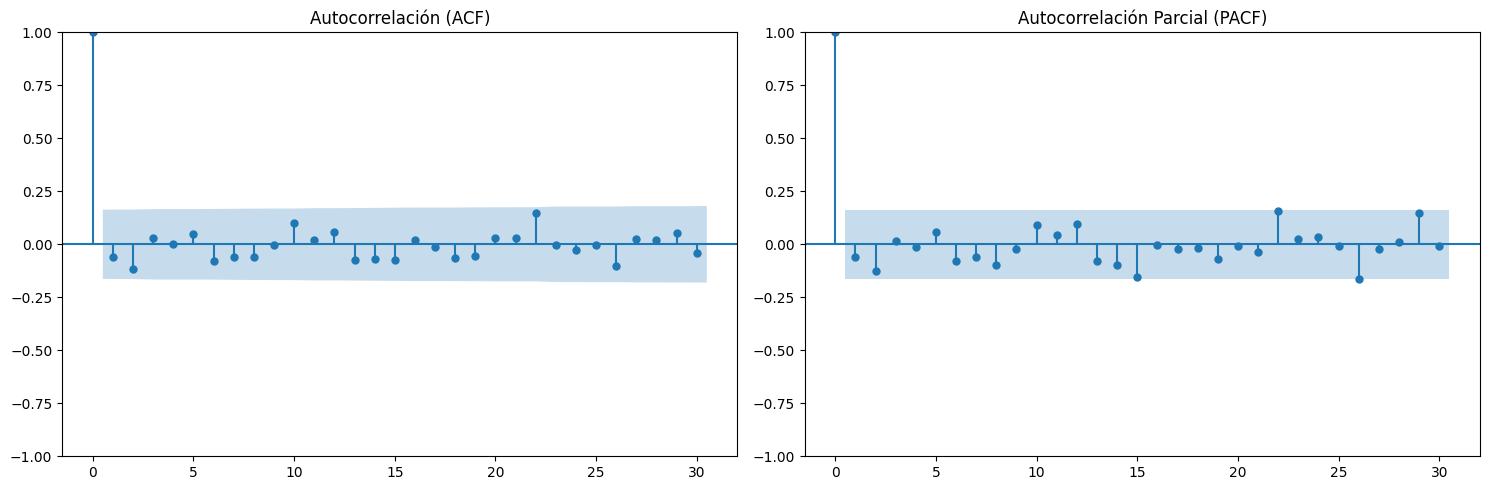

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3. Gráfico de Autocorrelación (ACF) - Útil para identificar el término MA (q)
plot_acf(df["diff_1"].dropna(), lags=30, ax=axes[0], title='Autocorrelación (ACF)')

# 4. Gráfico de Autocorrelación Parcial (PACF) - Útil para identificar el término AR (p)
plot_pacf(df["diff_1"].dropna(), lags=30, ax=axes[1], title='Autocorrelación Parcial (PACF)', method='yw')

plt.tight_layout()
plt.show()

---

## <font color= #6c9cda> *FNN* </font>

In [ ]:
serie_diff = df['diff_1'].dropna().values

# Definimos la función de ventana deslizante
def crear_ventanas(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 25
X, y = crear_ventanas(serie_diff, window_size=window_size)

# Escalado de Datos
scaler = StandardScaler()
# Escalamos X 
X_scaled = scaler.fit_transform(X)

# Split de Entrenamiento y Prueba 
split = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

In [150]:
# Construcción del modelo
model = Sequential([
    # Primera capa oculta de 32 neuronas
    Dense(64, activation='linear', input_shape=(window_size,)),
    Dropout(0.1),
    
    Dense(64, activation="relu"),
    Dropout(0.1), 
    
    # Capa de salida (predice el siguiente valor de diff_1)
    Dense(1) 
])

# Compilación
model.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    epochs=50,      # Aumenté a 100 para dar margen de aprendizaje
    batch_size=32,    # Batch pequeño suele ayudar en series de tiempo cortas
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


c:\Users\Roi_f\sexto_sem\Modelos_no_lineales\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - loss: 10878.3242 - mae: 59.7473 - val_loss: 8643.2109 - val_mae: 80.2315
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 10879.7510 - mae: 59.7268 - val_loss: 8648.4814 - val_mae: 80.2427
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10860.9453 - mae: 59.6908 - val_loss: 8653.0264 - val_mae: 80.2547
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 10847.4072 - mae: 59.5669 - val_loss: 8658.1680 - val_mae: 80.2698
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 10853.9248 - mae: 59.6247 - val_loss: 8665.0215 - val_mae: 80.2915
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 10831.9600 - mae: 59.5930 - val_loss: 8671.7695 - val_mae: 80.3124
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10817.2432 - mae: 59.4976 - val_loss: 8678.9873 - val_mae: 80.3360
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 10808.9082 - mae: 59.4611 - val_loss: 8686.4453 - val_mae: 80.3650
Epoch 9/50
3/3 ━━━

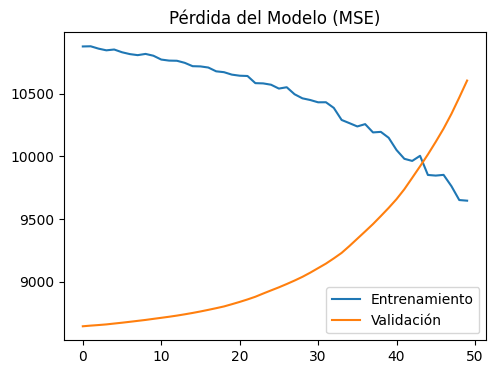

In [151]:
plt.figure(figsize=(12, 4))

# Gráfico de Pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo (MSE)')
plt.legend()

plt.show()

In [153]:
import plotly.graph_objects as go

fig_fnn = go.Figure()
y_pred = model.predict(X_test)

# Línea de valores reales
fig_fnn.add_trace(go.Scatter(
    y=y_test, 
    mode='lines', 
    name='Real (diff_1)',
    line=dict(color='royalblue', width=2)
))

# Línea de predicción de la red neuronal
fig_fnn.add_trace(go.Scatter(
    y=y_pred.flatten(), 
    mode='lines', 
    name='Predicción FNN',
    line=dict(color='firebrick', width=2, dash='dot')
))

fig_fnn.update_layout(
    title='Validación FNN: Predicción de Retornos (Set de Prueba)',
    xaxis_title='Muestras (Tiempo)',
    yaxis_title='Valor de diff_1',
    hovermode='x unified',
    template='plotly_white'
)

fig_fnn.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


---

## <font color= #6c9cda> *GARCH (O NO....)* </font>

Aqui va todo para GARCH

In [154]:
from arch import arch_model

# 1. Usamos la misma serie diferenciada
serie_garch = df['diff_1'].dropna()

# 2. Definir el punto de corte (80% entrenamiento, 20% prueba)
split_idx = int(len(serie_garch) * 0.8)
train_data = serie_garch.iloc[:split_idx]
test_data = serie_garch.iloc[split_idx:]

# 3. Configurar y Entrenar el modelo SOLO con train_data
model_train = arch_model(train_data, vol='Garch', p=1, q=1, dist='t')
res_train = model_train.fit(disp='off')

print("--- Resumen del Modelo (Entrenado con Train) ---")
print(res_train.summary())

--- Resumen del Modelo (Entrenado con Train) ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       diff_1   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -648.975
Distribution:      Standardized Student's t   AIC:                           1307.95
Method:                  Maximum Likelihood   BIC:                           1321.67
                                              No. Observations:                  115
Date:                      Sun, Apr 12 2026   Df Residuals:                      114
Time:                              00:22:35   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
----------------------------------------

In [ ]:
forecasts = res_train.forecast(horizon=len(test_data), reindex=False)

# Extraer la varianza pronosticada y convertir a desviación estándar (volatilidad)
vol_forecast = np.sqrt(forecasts.variance.values[-1])

In [70]:
# Preparar los datos
indices_test = test_data.index
# vol_test_series es la que calculamos previamente con np.sqrt(forecasts.variance...)
vol_test_series = pd.Series(vol_forecast, index=test_data.index)

fig_garch = go.Figure()

# Retornos reales en el set de prueba
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=test_data,
    mode='lines',
    name='Retornos Reales',
    line=dict(color='grey', width=1),
    opacity=0.5
))

# Banda Superior de Volatilidad
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=vol_test_series,
    mode='lines',
    line=dict(width=0),
    showlegend=False
))

# Banda Inferior de Volatilidad con Relleno (Shading)
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=-vol_test_series,
    mode='lines',
    line=dict(width=0),
    fill='tonexty', # Rellena hacia la traza anterior
    fillcolor='rgba(255, 0, 0, 0.2)',
    name='Volatilidad Pronosticada (Intervalo)'
))

# Línea de contorno para que se vea definida
fig_garch.add_trace(go.Scatter(
    x=indices_test, y=vol_test_series,
    mode='lines',
    line=dict(color='red', width=2),
    name='Límite de Volatilidad'
))

fig_garch.update_layout(
    title='Validación GARCH: Pronóstico de Volatilidad (Out-of-Sample)',
    xaxis_title='Fecha',
    yaxis_title='Magnitud',
    template='plotly_dark', # El modo oscuro resalta muy bien las bandas rojas
    hovermode='x unified'
)

fig_garch.show()

---

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="imgs/ivanmamado.png" width="300">
</div>

---